In [34]:
# Load & Inspect Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('../data/raw/cs-training.csv', index_col=0)
print(df.shape)
print(df.head(5))

(150000, 11)
   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
1                 1                              0.766127   45   
2                 0                              0.957151   40   
3                 0                              0.658180   38   
4                 0                              0.233810   30   
5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
1                                     2   0.802982         9120.0   
2                                     0   0.121876         2600.0   
3                                     1   0.085113         3042.0   
4                                     0   0.036050         3300.0   
5                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
1                               13                        0   
2                                4               

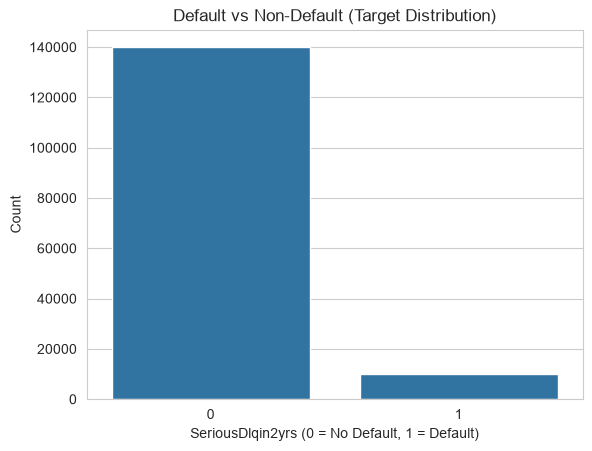

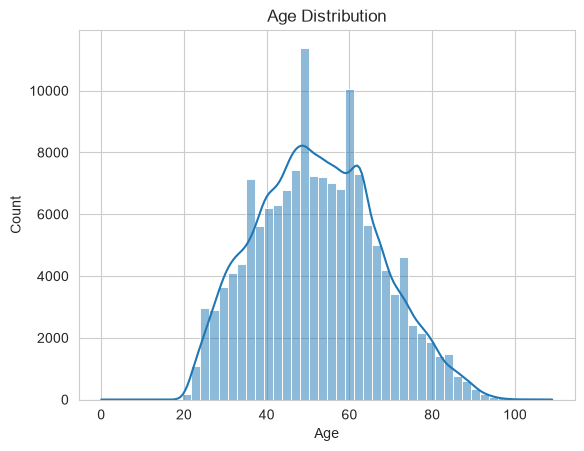

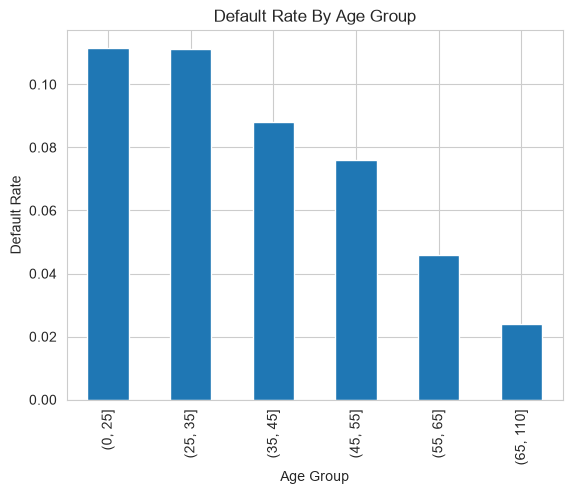

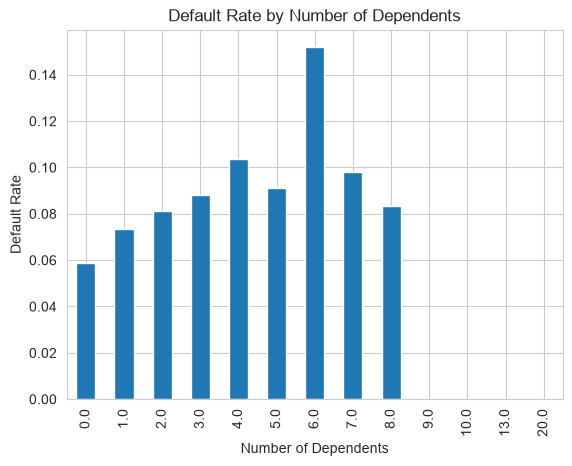

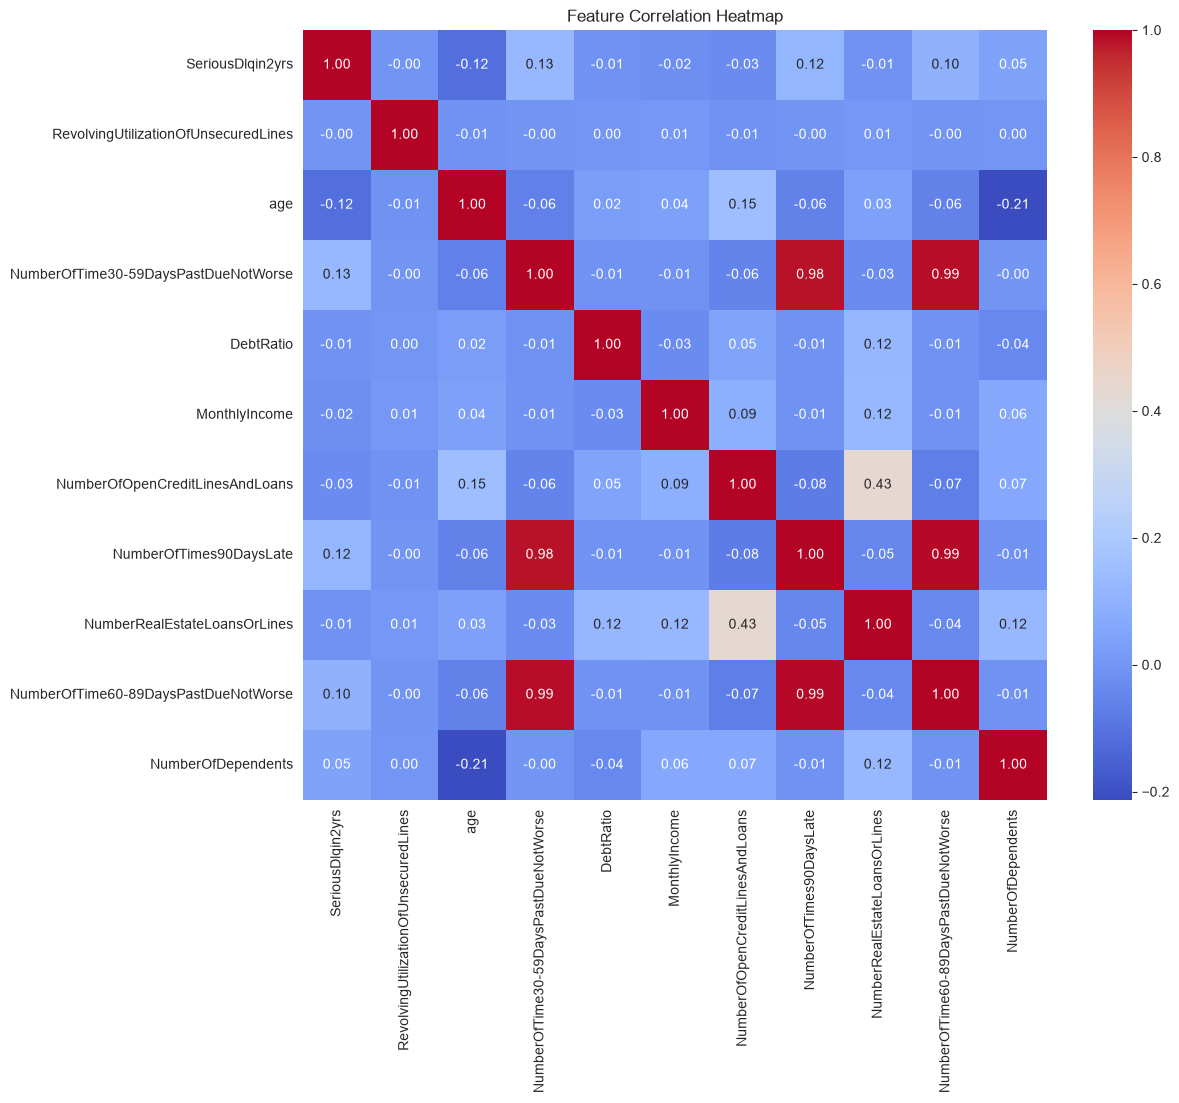

Missing values

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
age_bucket                                  1
dtype: int64


In [37]:
#Exploratory Data Analysis (EDA)
#Target Distribution
sns.countplot(x='SeriousDlqin2yrs', data=df)
plt.title('Default vs Non-Default (Target Distribution)')
plt.xlabel('SeriousDlqin2yrs (0 = No Default, 1 = Default)')
plt.ylabel('Count')
plt.show()

#Age Chart
sns.histplot(df['age'], bins = 50, kde = True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

#rate by age group
df['age_bucket'] = pd.cut(df['age'], bins = [0, 25, 35, 45, 55, 65, 110])
default_by_age = df.groupby('age_bucket')['SeriousDlqin2yrs'].mean()
default_by_age.plot(kind='bar')
plt.title("Default Rate By Age Group")
plt.xlabel('Age Group')
plt.ylabel('Default Rate')
plt.show()

#rate by dependents
default_by_dependents = df.groupby('NumberOfDependents')['SeriousDlqin2yrs'].mean()

default_by_dependents.plot(kind='bar')
plt.title('Default Rate by Number of Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Default Rate')
plt.show()

#heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.drop(columns=['age_bucket']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

#check before cleaning
print("Missing values\n")
print(df.isnull().sum())

In [22]:
# Data Cleaning
df_clean = df.copy()

# Drop the row with age = 0
df_clean = df_clean[df_clean['age'] > 0]

# Fill missing MonthlyIncome with the median income
median_income = df_clean['MonthlyIncome'].median()
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(median_income)

#  Flag which rows originally had missing income
# (using the original df, since df_clean's nulls are already filled)
df_clean['income_was_missing'] = df['MonthlyIncome'].isnull().astype(int)

# DebtRatio was corrupted for rows where income was originally missing
# (debt / near-zero income = huge broken ratio)
# Fix: replace DebtRatio for those rows with the median DebtRatio
# calculated only from rows where income was reliable
reliable_debt_ratio_median = df_clean.loc[df_clean['income_was_missing'] == 0, 'DebtRatio'].median()
df_clean.loc[df_clean['income_was_missing'] == 1, 'DebtRatio'] = reliable_debt_ratio_median

# Cap remaining extreme DebtRatio values (genuine outliers, not missing-income related)
# using the 99th percentile of the reliable rows
debt_ratio_99th = df_clean.loc[df_clean['income_was_missing'] == 0, 'DebtRatio'].quantile(0.99)
df_clean['DebtRatio'] = df_clean['DebtRatio'].clip(upper=debt_ratio_99th)

# Cap RevolvingUtilizationOfUnsecuredLines outliers at the 99th percentile
# (this column's outliers were unrelated to missing income - just bad data)
util_99th = df_clean['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)
df_clean['RevolvingUtilizationOfUnsecuredLines'] = df_clean['RevolvingUtilizationOfUnsecuredLines'].clip(upper=util_99th)

# Fill missing NumberOfDependents
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(0)

# Final check
print(df_clean.isnull().sum())

# Validating
print('RevolvingUtilization correlation before cleaning:',
      df['RevolvingUtilizationOfUnsecuredLines'].corr(df['SeriousDlqin2yrs']))
print('RevolvingUtilization correlation after cleaning:',
      df_clean['RevolvingUtilizationOfUnsecuredLines'].corr(df_clean['SeriousDlqin2yrs']))

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
age_bucket                              0
income_was_missing                      0
dtype: int64
RevolvingUtilization correlation before cleaning: -0.001801502503943969
RevolvingUtilization correlation after cleaning: 0.28081971933521915


In [23]:
#Feature Engineering

In [24]:
#Train/Test Split

In [25]:
#Baseline Model — Logistic Regression

In [26]:
#Handle Class Imbalance (class weighting + SMOTE)

In [27]:
#Stronger Model — XGBoost

In [28]:
#Evaluation — compare all models

In [29]:
#Threshold Tuning — tie back to business problem

In [30]:
#Feature Importance / SHAP

In [31]:
#Save Model for Deployment